In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# Load the dataset
df = pd.read_csv("/content/crime_dataset_with_unemployment.csv")

In [3]:
# 1. Handle Missing Values
print("Missing values before handling:\n", df.isnull().sum())

Missing values before handling:
 State/UT                                                           0
Year                                                               0
Total Cognizable IPC Crimes                                        0
Crime Rate (IPC)                                                   0
Murder (Section 302 IPC)                                           0
Culpable Homicide not amounting to Murder (Section 299/304 IPC)    0
Rape (Section 375/376 IPC)                                         0
Literacy Rate (%)                                                  0
Poverty Rate (%)                                                   0
Police Strength: police personnel per 100000 population            0
Unemployment Rate (%)                                              0
dtype: int64


In [2]:
# 2. Encode Categorical Variables
# Use Label Encoding for 'State/UT'
label_encoder = LabelEncoder()
df['State/UT'] = label_encoder.fit_transform(df['State/UT'])



In [4]:
# 3. Feature Scaling
# Select numerical columns for scaling
numerical_cols = ['Year', 'Total Cognizable IPC Crimes', 'Crime Rate (IPC)',
                  'Murder (Section 302 IPC)', 'Culpable Homicide not amounting to Murder (Section 299/304 IPC)',
                  'Rape (Section 375/376 IPC)', 'Literacy Rate (%)', 'Poverty Rate (%)']

In [5]:
# Initialize Min-Max Scaler
scaler = MinMaxScaler()

In [6]:
# Fit and transform the numerical columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [7]:
# Display the first few rows of the preprocessed data
print("\nPreprocessed Data:")
print(df.head())


Preprocessed Data:
   State/UT  Year  Total Cognizable IPC Crimes  Crime Rate (IPC)  \
0         1  0.00                     0.093885          0.103059   
1         1  0.25                     0.107396          0.120581   
2         1  0.50                     0.105001          0.117574   
3         1  0.75                     0.105762          0.117833   
4         1  1.00                     0.172800          0.208087   

   Murder (Section 302 IPC)  \
0                  0.229699   
1                  0.215586   
2                  0.191246   
3                  0.177951   
4                  0.174473   

   Culpable Homicide not amounting to Murder (Section 299/304 IPC)  \
0                                           0.057679                 
1                                           0.140375                 
2                                           0.184851                 
3                                           0.127172                 
4                                 

In [8]:
# Display the data types of the columns
print("\nData Types:")
print(df.dtypes)


Data Types:
State/UT                                                             int64
Year                                                               float64
Total Cognizable IPC Crimes                                        float64
Crime Rate (IPC)                                                   float64
Murder (Section 302 IPC)                                           float64
Culpable Homicide not amounting to Murder (Section 299/304 IPC)    float64
Rape (Section 375/376 IPC)                                         float64
Literacy Rate (%)                                                  float64
Poverty Rate (%)                                                   float64
Police Strength: police personnel per 100000 population            float64
Unemployment Rate (%)                                              float64
dtype: object


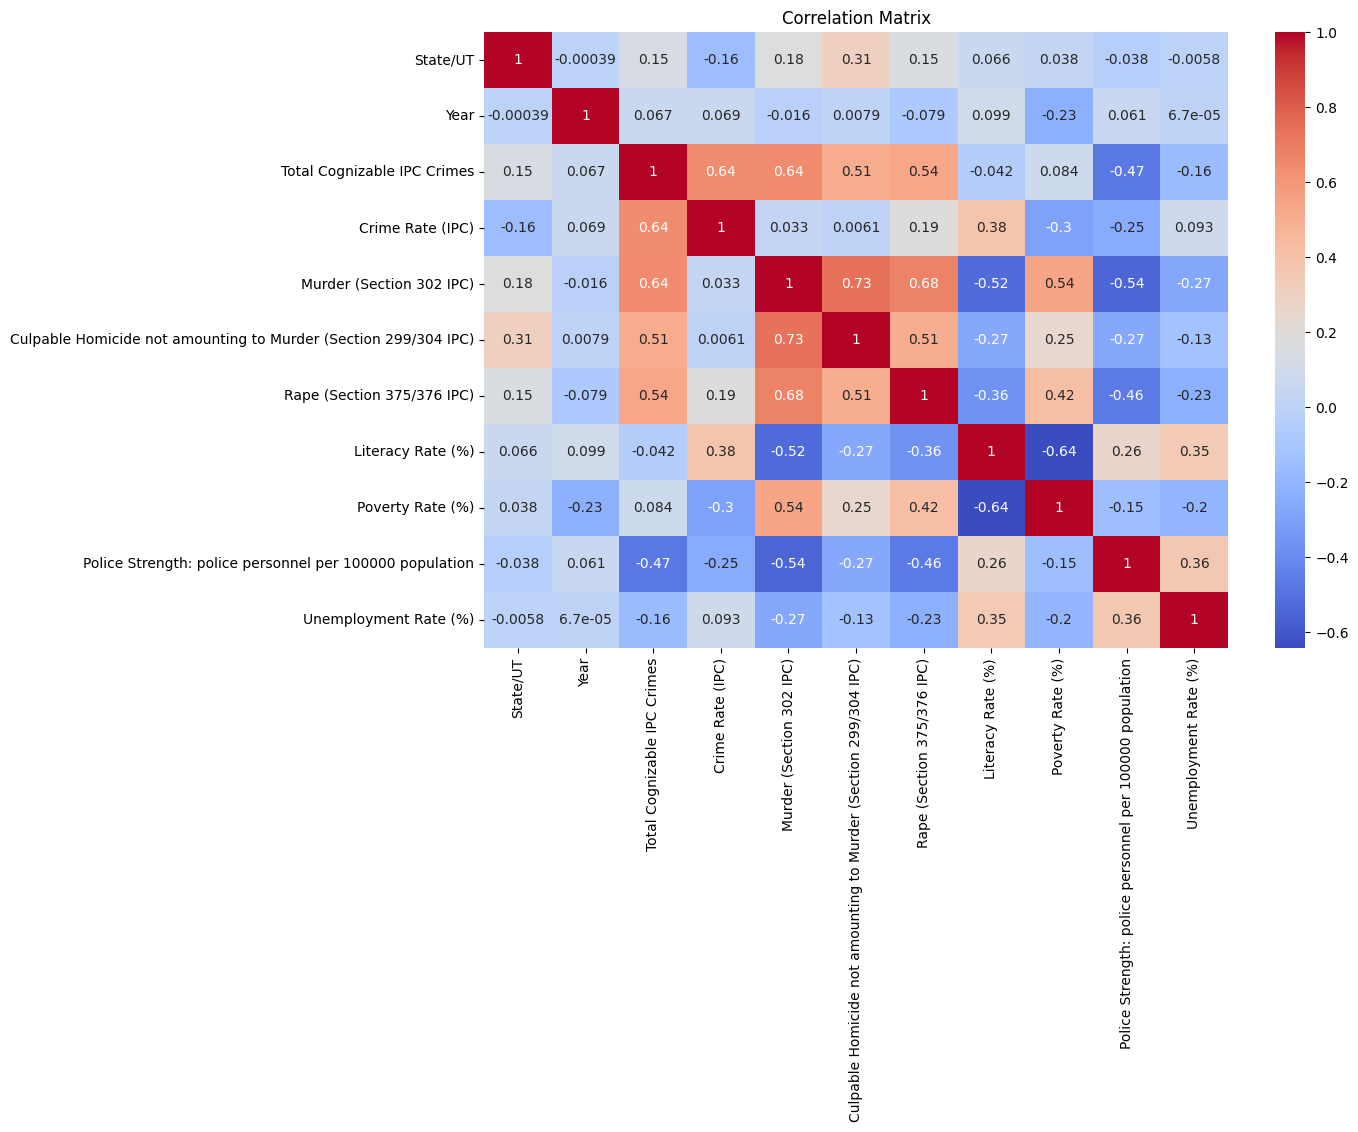

In [9]:
# 1. Correlation Analysis
import matplotlib.pyplot as plt # Import the matplotlib library
import seaborn as sns # Import the seaborn library
correlation_matrix = df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [10]:
# 2. Feature Importance using Random Forest
from sklearn.model_selection import train_test_split # Import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = df.drop('Crime Rate (IPC)', axis=1)  # Features
y = df['Crime Rate (IPC)']  # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

feature_importances = model.feature_importances_

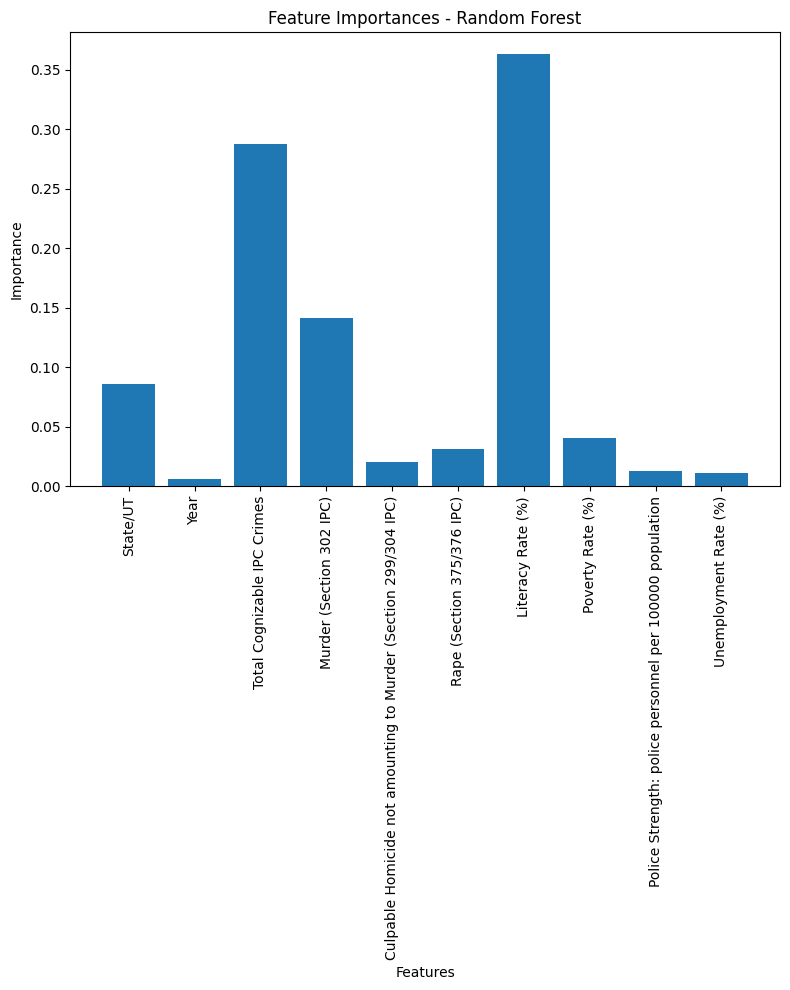

In [11]:
# Plot feature importances
features = X.columns
indices = range(len(features))
plt.figure(figsize=(8, 10))
plt.bar(indices, feature_importances, align='center')
plt.xticks(indices, features, rotation='vertical')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importances - Random Forest')
plt.tight_layout()
plt.show()